# Preprocessing, Augmentation & Feature Extraction
## Dataset Preparation, Preprocessing,
## Balanced Augmentation Strategy & Feature Extraction Pipeline

This notebook covers:
- Dataset loading and class distribution analysis
- Stratified train/test split (lesion ID based)
- Feature extraction using ResNet-50

In [1]:
# Libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torchvision.models as models
import torchvision.transforms as transforms

## Paths & Settings

In [2]:
# Paths
METADATA_PATH = '../data/raw/HAM10000_metadata.csv'
IMAGE_FOLDER  = '../data/raw/images'
OUTPUT_DIR    = '../data/processed'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Output directory ready:", OUTPUT_DIR)

Output directory ready: ../data/processed


## Dataset Loading & Class Distribution Analysis

Total images: 10015

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


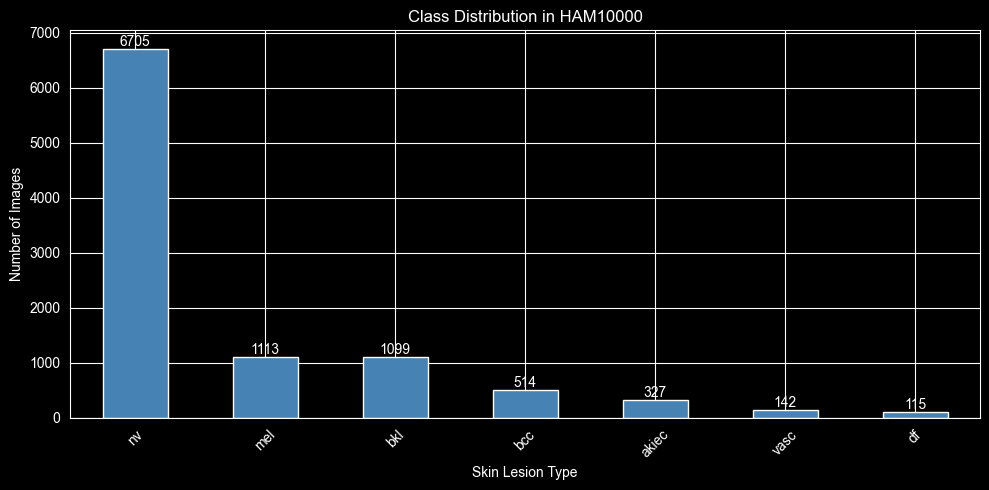

In [3]:
# Load metadata
df = pd.read_csv(METADATA_PATH)
print("Total images:", len(df))
print("\nClass distribution:")
print(df['dx'].value_counts())

# Plot class distribution
plt.figure(figsize=(10, 5))
ax = df['dx'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Class Distribution in HAM10000')
plt.xlabel('Skin Lesion Type')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

## Train/Test Split
- 80/20 stratified split
- Split is based on lesion_id to prevent data leakage
- (Same lesion's multiple images won't appear in both train and test)

In [4]:
# Split by lesion_id to prevent data leakage
unique_lesions = df.drop_duplicates(subset='lesion_id')

train_lesions, test_lesions = train_test_split(
    unique_lesions['lesion_id'],
    test_size=0.2,
    stratify=unique_lesions['dx'],
    random_state=42
)

train_df = df[df['lesion_id'].isin(train_lesions)].reset_index(drop=True)
test_df  = df[df['lesion_id'].isin(test_lesions)].reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size: ", len(test_df))
print("\nTrain class distribution:")
print(train_df['dx'].value_counts())
print("\nTest class distribution:")
print(test_df['dx'].value_counts())

# Save
train_df.to_csv('../data/processed/train_split.csv', index=False)
test_df.to_csv('../data/processed/test_split.csv',  index=False)
print("\nSaved: train_split.csv and test_split.csv")

Train size: 8020
Test size:  1995

Train class distribution:
dx
nv       5368
mel       895
bkl       881
bcc       414
akiec     265
vasc      110
df         87
Name: count, dtype: int64

Test class distribution:
dx
nv       1337
bkl       218
mel       218
bcc       100
akiec      62
vasc       32
df         28
Name: count, dtype: int64

Saved: train_split.csv and test_split.csv


## Balanced Dataset Strategy
- nv (majority class): kept at original count (5368) — no undersampling
- All minority classes: oversampled to 3000 via augmentation
- Total training samples: 23,368
- Note: This notebook uses frozen ResNet-50 (initial approach)
  Final pipeline uses fine-tuned ResNet-50 (see 02_model_training.ipynb)

In [5]:
# Target counts for balancing
TARGET_COUNTS = {
    'nv': 6705,    # Keep original (no information lost)
    'mel': 3000,   # Boosted for a fair comparison
    'bkl': 3000,
    'bcc': 3000,
    'akiec': 3000,
    'vasc': 3000,
    'df': 3000
}

# Single class mapping — used everywhere
CLASS_NAMES = list(TARGET_COUNTS.keys())
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Add numeric label index to dataframes
train_df['label_idx'] = train_df['dx'].map(CLASS_TO_IDX)
test_df['label_idx']  = test_df['dx'].map(CLASS_TO_IDX)

print("Class mapping:")
for name, idx in CLASS_TO_IDX.items():
    print(f"  {idx} = {name}")

Class mapping:
  0 = nv
  1 = mel
  2 = bkl
  3 = bcc
  4 = akiec
  5 = vasc
  6 = df


## Augmentation Transforms
- Standard transform: resize + normalize (for test set)
- Augmentation transform: flip + rotation + color jitter (for minority classes)

In [6]:
# Standard transform — test set only
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Augmentation transform — Updated with RandomResizedCrop to prevent overfitting
train_aug_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Resize slightly larger before cropping
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=90),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms defined.")

Transforms defined.


## Balanced Dataset Creation
- Oversample minority classes by repeating with replacement
- Augmentation applied during feature extraction via DataLoader

In [7]:
from torch.utils.data import Dataset, DataLoader

class BalancedSkinDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df        = dataframe
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(
            self.image_dir,
            f"{self.df.iloc[idx]['image_id']}.jpg"
        )
        image = Image.open(img_path).convert('RGB')
        label = self.df.iloc[idx]['label_idx']

        if self.transform:
            image = self.transform(image)

        return image, label

# Build balanced training dataframe
balanced_train_list = []
for class_name, target in TARGET_COUNTS.items():
    class_subset = train_df[train_df['dx'] == class_name]

    if class_name == 'nv':
        # Rule: Never undersample the majority medical class
        balanced_train_list.append(class_subset)
    else:
        # Rule: Oversample minority classes to reach target
        balanced_train_list.append(
            class_subset.sample(n=target, replace=True, random_state=42)
        )

balanced_train_df = pd.concat(balanced_train_list).reset_index(drop=True)

print("Balanced Training Set Distribution:")
print(balanced_train_df['dx'].value_counts())
print("\nTotal training samples:", len(balanced_train_df))

Balanced Training Set Distribution:
dx
nv       5368
mel      3000
bkl      3000
bcc      3000
akiec    3000
vasc     3000
df       3000
Name: count, dtype: int64

Total training samples: 23368


## Feature Extraction with ResNet-50
- Pre-trained on ImageNet
- Classification head removed
- Each image → 2048-dimensional feature vector
- Train set: augmentation transform applied
- Test set: standard transform only

In [8]:
# Load ResNet-50, ensure global pooling is captured
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# We keep everything up to the global average pooling layer
feature_extractor = torch.nn.Sequential(
    *list(resnet.children())[:-1],
    torch.nn.Flatten() # Resulting shape will be (Batch, 2048)
)
feature_extractor.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
feature_extractor.to(device)
print(f"Using device: {device}")

def extract_features(dataset_df, transform):
    # Double check your image directory path here!
    dataset = BalancedSkinDataset(
        dataset_df,
        image_dir='../data/raw/images',
        transform=transform
    )
    # Using pin_memory=True speeds up transfer to GPU
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

    features_list = []
    labels_list   = []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            feats = feature_extractor(imgs)
            features_list.append(feats.cpu().numpy())
            labels_list.append(lbls.numpy())

    return np.concatenate(features_list), np.concatenate(labels_list)

print("Feature extractor ready.")

Using device: cpu
Feature extractor ready.


## Run Feature Extraction
⚠️ This cell takes ~45-60 minutes on CPU.
Train set uses augmentation transform.
Test set uses standard transform (no augmentation).

In [ ]:
print("Extracting features for training set (with augmentation)...")
X_train, y_train = extract_features(balanced_train_df, train_aug_transform)
print(f"Train features shape: {X_train.shape}")

print("\nExtracting features for test set (standard)...")
X_test, y_test = extract_features(test_df, base_transform)
print(f"Test features shape: {X_test.shape}")

# Save
np.save('../data/processed/X_train_resnet.npy', X_train)
np.save('../data/processed/y_train.npy',         y_train)
np.save('../data/processed/X_test_resnet.npy',   X_test)
np.save('../data/processed/y_test.npy',           y_test)

print("\n✓ Feature extraction complete. Files saved:")
print("  - X_train_resnet.npy", X_train.shape)
print("  - y_train.npy        ", y_train.shape)
print("  - X_test_resnet.npy  ", X_test.shape)
print("  - y_test.npy         ", y_test.shape)

Extracting features for training set (with augmentation)...


D:\master\BBL514E\term_project\skin-lesion-diagnosis-v2\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
